总数据量: 323598
清洗后（去除关键列缺失）: 313003
买粉过滤: 剔除 15972 条 (粉丝前10%但互动率<1%)
过滤后数据量: 297031
最终可用数据量: 296356

📊 星期几效应分析
    weekday    样本量         平均点赞   中位点赞        平均评论        平均收藏        平均总互动   平均log互动
星期                                                                                   
周一        0  41021  1789.074888  155.0  131.347115  622.267034  2936.730382  5.947015
周二        1  39963  1801.761805  118.0  123.080099  678.540725  2972.622926  5.779208
周三        2  42019  1748.507770  107.0  115.837145  670.289774  2882.146124  5.731680
周四        3  46040  1732.298219   92.0  121.401151  641.574978  2859.477802  5.608308
周五        4  53669  1466.804654   54.0  106.464067  513.175520  2405.836442  5.010181
周六        5  38766  1995.461229  128.0  129.729557  711.542254  3225.921710  5.837044
周日        6  34878  1949.439733  121.0  124.631716  691.407391  3139.373989  5.795335

单因素 ANOVA (按星期): F = 946.56, p = 0.00e+00
效应量 η² = 0.018804

Tukey HSD 事后检验：
Multiple Comparison of Means - Tukey HS

C:\Users\fire\AppData\Local\Temp\ipykernel_23772\2931799967.py:183: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_weekday, labels=weekday_cn, patch_artist=True)


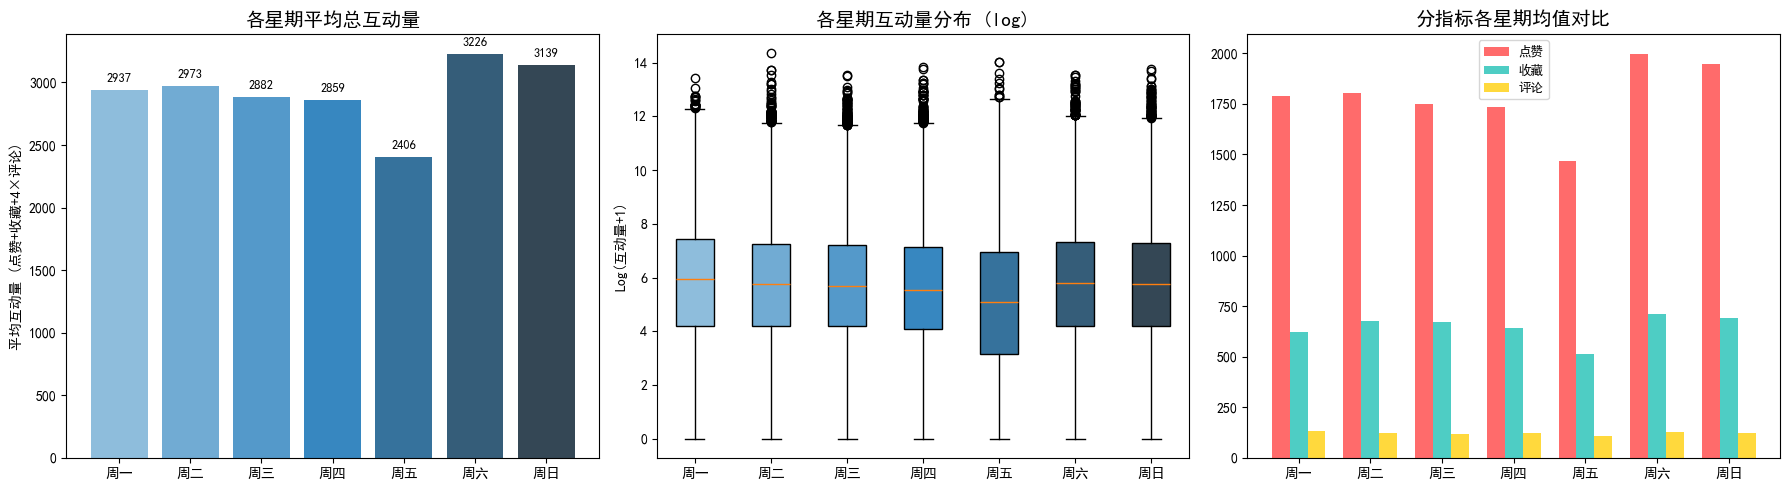


🎉 节假日效应分析
              样本量         平均点赞   中位点赞        平均评论         平均收藏        平均总互动   平均log互动
date_type                                                                            
普通工作日      218770  1684.192110  100.0  118.213215   615.610797  2772.655766  5.571441
普通周末        67445  1888.246986  121.0  124.361495   662.956320  3048.649285  5.792035
调休工作日        1619  2825.389129  220.0  135.180358  1378.516368  4744.626930  6.284323
节假日          8522  2618.132246  145.0  162.544943   934.480990  4202.793006  6.051481

节假日 vs 非节假日：
         样本量         平均点赞        平均评论        平均收藏        平均总互动   平均log互动
非节假日  287834  1738.425033  119.749310  630.995925  2848.418199  5.627140
节假日     8522  2618.132246  162.544943  934.480990  4202.793006  6.051481

Welch t检验: t = 18.75, p = 4.86e-77
Cohen's d = 0.1960
四组 ANOVA: F = 305.53, p = 4.49e-198


C:\Users\fire\AppData\Local\Temp\ipykernel_23772\2931799967.py:266: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['非节假日', '节假日'], patch_artist=True)


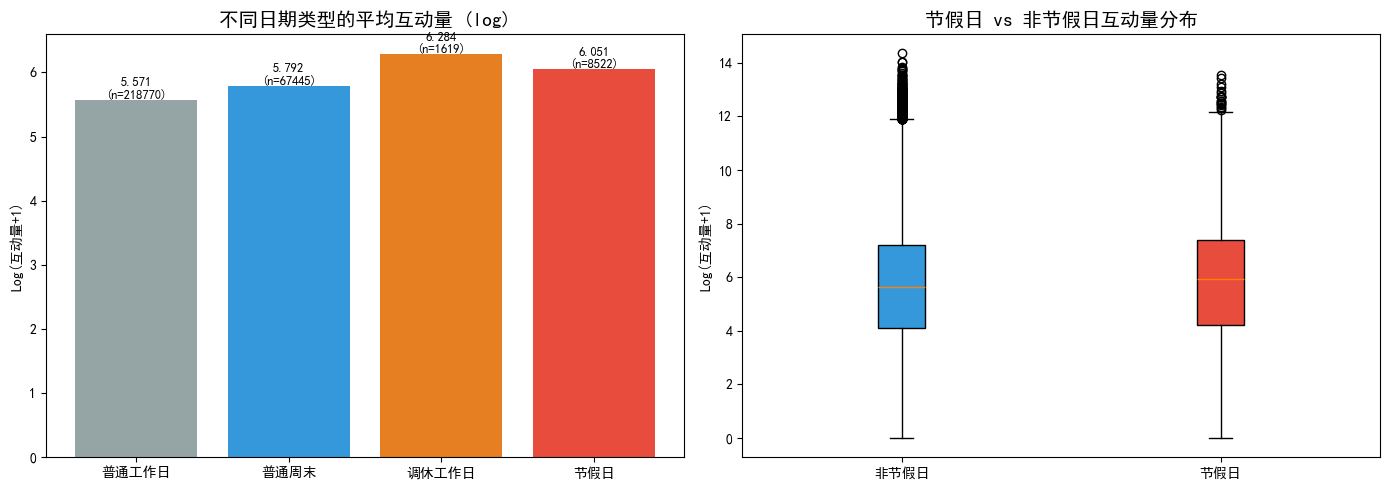


📍 发布地省份分析
有效发布地数据量: 125745

共有 96 个省份/地区

样本量前20省份：
            样本量        平均总互动   平均log互动          平均粉丝
province                                            
广东        25624  2289.524781  5.234217  17226.067958
浙江        12723  3569.423721  5.972714  38018.970588
江苏         7460  2856.364611  5.597476  20598.391854
河南         6857  2736.754266  5.275906  12371.136271
山东         6379  2571.891989  5.449971  14326.789491
上海         6376  2984.660445  5.870312  32155.943777
湖南         6170  2357.077796  5.742209  19137.278849
四川         6129  3572.612824  5.884737  26264.033403
北京         5643  3474.526847  5.673891  34429.215267
福建         4569  3088.439265  5.650546  19971.645459
湖北         3661  2670.468998  5.698996  22987.196413
广西         3494  1574.567258  5.568541   8809.784424
安徽         3151  2695.642336  5.594386  15678.529412
河北         2992  2510.054144  5.250574  12824.311540
重庆         2644  3484.290469  5.757144  21660.162424
辽宁         2627  3061.569090  5.561111  18418.

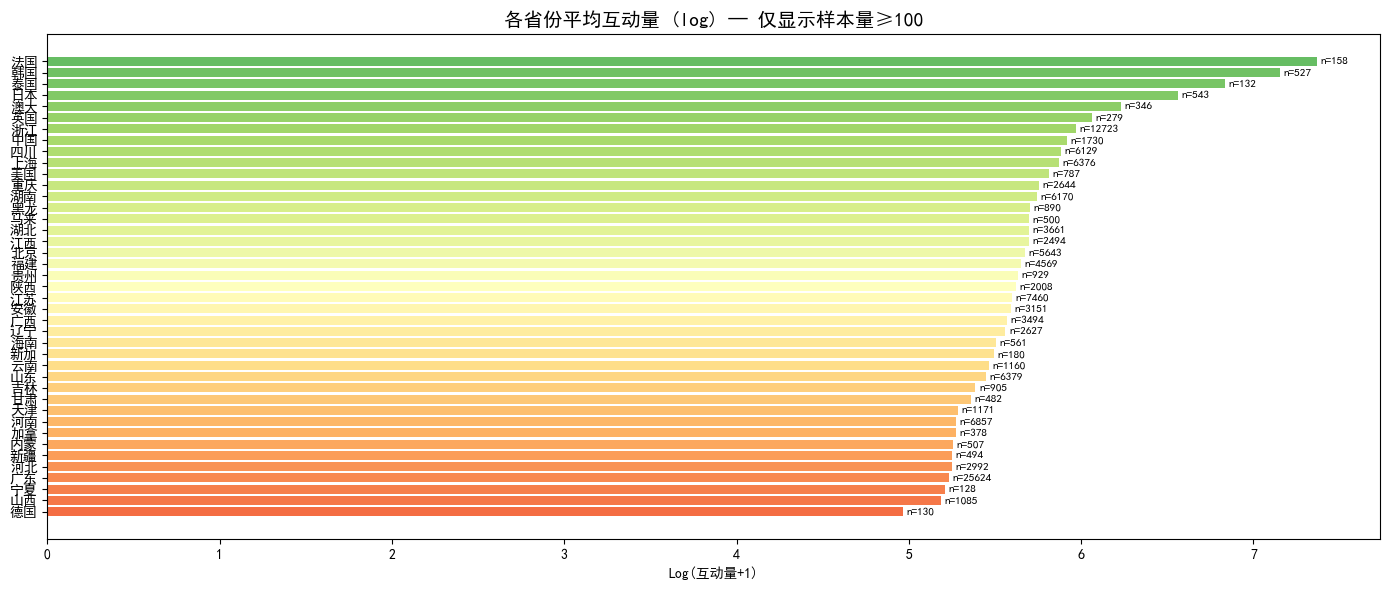


✅ 全部分析完成！


In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 0. 读取全部数据
# ==========================================
folder_path = r"C:\Users\fire\all2"
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

df_list = []
for f in all_files:
    try:
        df_list.append(pd.read_csv(f, encoding='utf-8-sig'))
    except Exception as e:
        print(f"跳过 {os.path.basename(f)}: {e}")

df = pd.concat(df_list, ignore_index=True)
print(f"总数据量: {len(df)}")

# ==========================================
# 1. 数据清洗
# ==========================================
df['likes']    = pd.to_numeric(df['相对准确点赞数'], errors='coerce')
df['comments'] = pd.to_numeric(df['相对准确评论数'], errors='coerce')
df['favs']     = pd.to_numeric(df['相对准确收藏数'], errors='coerce')
df['fans']     = pd.to_numeric(df['相对准确粉丝数'], errors='coerce')

df = df.dropna(subset=['likes', 'comments', 'favs'])
print(f"清洗后（去除关键列缺失）: {len(df)}")

# ==========================================
# 1.5 买粉过滤（关键！）
# ==========================================
df['engagement'] = df['likes'] + df['favs'] + 4 * df['comments']
df['fans'] = df['fans'].replace(0, np.nan)  # 避免除零
df['engagement_rate'] = df['engagement'] / df['fans']

fan_threshold = df['fans'].quantile(0.9)
before_filter = len(df)
df = df[~(
    (df['fans'] > fan_threshold) &
    (df['engagement_rate'] < 0.01)
)]
after_filter = len(df)
print(f"买粉过滤: 剔除 {before_filter - after_filter} 条 (粉丝前10%但互动率<1%)")
print(f"过滤后数据量: {after_filter}")

# ==========================================
# 1.6 继续构造变量
# ==========================================
df['engagement_log'] = np.log1p(df['engagement'])

df['post_date'] = pd.to_datetime(df['推断笔记发布日期'], errors='coerce')
df = df.dropna(subset=['post_date'])

df['weekday'] = df['post_date'].dt.dayofweek  # 0=Monday ... 6=Sunday
df['weekday_name'] = df['post_date'].dt.day_name()

df['location'] = df['笔记发布地'].astype(str)
df['location_valid'] = (~df['location'].isin(['-9999', 'nan', ''])) & (df['location'].str.strip() != '')

print(f"最终可用数据量: {len(df)}")

# ==========================================
# 2. 定义节假日（2023 + 2024 中国法定节假日+调休）
# ==========================================
holiday_list = [
    # 2023 春节
    '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24', '2023-01-25', '2023-01-26', '2023-01-27',
    # 2023 清明
    '2023-04-05',
    # 2023 劳动节
    '2023-04-29', '2023-04-30', '2023-05-01', '2023-05-02', '2023-05-03',
    # 2023 端午
    '2023-06-22', '2023-06-23', '2023-06-24',
    # 2023 中秋+国庆
    '2023-09-29', '2023-09-30', '2023-10-01', '2023-10-02', '2023-10-03', '2023-10-04', '2023-10-05', '2023-10-06',
    # 2024 元旦（跨年）
    '2023-12-30', '2023-12-31', '2024-01-01',
    # 2024 春节
    '2024-02-10', '2024-02-11', '2024-02-12', '2024-02-13', '2024-02-14', '2024-02-15', '2024-02-16', '2024-02-17',
    # 2024 清明
    '2024-04-04', '2024-04-05', '2024-04-06',
    # 2024 劳动节
    '2024-05-01', '2024-05-02', '2024-05-03', '2024-05-04', '2024-05-05',
    # 2024 端午
    '2024-06-08', '2024-06-09', '2024-06-10',
    # 2024 中秋
    '2024-09-15', '2024-09-16', '2024-09-17',
    # 2024 国庆
    '2024-10-01', '2024-10-02', '2024-10-03', '2024-10-04', '2024-10-05', '2024-10-06', '2024-10-07',
]

workday_shift = [
    '2023-01-28', '2023-01-29',
    '2023-04-23',
    '2023-05-06',
    '2023-06-25',
    '2023-10-07', '2023-10-08',
    '2024-02-04', '2024-02-18',
    '2024-04-07',
    '2024-04-28', '2024-05-11',
    '2024-09-14',
    '2024-09-29', '2024-10-12',
]

holiday_set = set(pd.to_datetime(holiday_list))
workday_shift_set = set(pd.to_datetime(workday_shift))

def classify_date(d):
    if d in holiday_set:
        return '节假日'
    elif d in workday_shift_set:
        return '调休工作日'
    elif d.dayofweek >= 5:
        return '普通周末'
    else:
        return '普通工作日'

df['date_type'] = df['post_date'].apply(classify_date)
df['is_holiday'] = df['date_type'] == '节假日'

# ==========================================
# 3. 星期几效应分析
# ==========================================
print("\n" + "=" * 60)
print("📊 星期几效应分析")
print("=" * 60)

weekday_cn = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']

weekday_stats = df.groupby('weekday').agg(
    样本量=('engagement', 'count'),
    平均点赞=('likes', 'mean'),
    中位点赞=('likes', 'median'),
    平均评论=('comments', 'mean'),
    平均收藏=('favs', 'mean'),
    平均总互动=('engagement', 'mean'),
    平均log互动=('engagement_log', 'mean'),
).reset_index()
weekday_stats['星期'] = weekday_stats['weekday'].apply(lambda x: weekday_cn[x])
weekday_stats = weekday_stats.set_index('星期')

print(weekday_stats.to_string())

# ANOVA
groups = [df[df['weekday'] == i]['engagement_log'].values for i in range(7)]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\n单因素 ANOVA (按星期): F = {f_stat:.2f}, p = {p_value:.2e}")

grand_mean = df['engagement_log'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total = sum((df['engagement_log'] - grand_mean)**2)
eta_sq = ss_between / ss_total
print(f"效应量 η² = {eta_sq:.6f}")

print("\nTukey HSD 事后检验：")
tukey = pairwise_tukeyhsd(df['engagement_log'], df['weekday'], alpha=0.05)
print(tukey)

# ---- 可视化 ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
means = weekday_stats['平均总互动']
ax.bar(weekday_cn, means, color=sns.color_palette("Blues_d", 7))
ax.set_title('各星期平均总互动量', fontsize=14)
ax.set_ylabel('平均互动量 (点赞+收藏+4×评论)')
for i, v in enumerate(means):
    ax.text(i, v + max(means)*0.02, f'{v:.0f}', ha='center', fontsize=9)

ax = axes[1]
data_by_weekday = [df[df['weekday'] == i]['engagement_log'].values for i in range(7)]
bp = ax.boxplot(data_by_weekday, labels=weekday_cn, patch_artist=True)
for patch, color in zip(bp['boxes'], sns.color_palette("Blues_d", 7)):
    patch.set_facecolor(color)
ax.set_title('各星期互动量分布 (log)', fontsize=14)
ax.set_ylabel('Log(互动量+1)')

ax = axes[2]
x = np.arange(7)
w = 0.25
ax.bar(x - w, weekday_stats['平均点赞'], w, label='点赞', color='#FF6B6B')
ax.bar(x,      weekday_stats['平均收藏'], w, label='收藏', color='#4ECDC4')
ax.bar(x + w, weekday_stats['平均评论'], w, label='评论', color='#FFD93D')
ax.set_xticks(x)
ax.set_xticklabels(weekday_cn)
ax.set_title('分指标各星期均值对比', fontsize=14)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('weekday_effect.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 4. 节假日效应分析
# ==========================================
print("\n" + "=" * 60)
print("🎉 节假日效应分析")
print("=" * 60)

date_type_stats = df.groupby('date_type').agg(
    样本量=('engagement', 'count'),
    平均点赞=('likes', 'mean'),
    中位点赞=('likes', 'median'),
    平均评论=('comments', 'mean'),
    平均收藏=('favs', 'mean'),
    平均总互动=('engagement', 'mean'),
    平均log互动=('engagement_log', 'mean'),
).reindex(['普通工作日', '普通周末', '调休工作日', '节假日'])

print(date_type_stats.to_string())

holiday_vs_rest = df.groupby('is_holiday').agg(
    样本量=('engagement', 'count'),
    平均点赞=('likes', 'mean'),
    平均评论=('comments', 'mean'),
    平均收藏=('favs', 'mean'),
    平均总互动=('engagement', 'mean'),
    平均log互动=('engagement_log', 'mean'),
)
holiday_vs_rest.index = ['非节假日', '节假日']
print("\n节假日 vs 非节假日：")
print(holiday_vs_rest.to_string())

holiday_vals = df[df['is_holiday']]['engagement_log']
non_holiday_vals = df[~df['is_holiday']]['engagement_log']
t_stat, t_p = stats.ttest_ind(holiday_vals, non_holiday_vals, equal_var=False)
print(f"\nWelch t检验: t = {t_stat:.2f}, p = {t_p:.2e}")

pooled_std = np.sqrt((holiday_vals.var() + non_holiday_vals.var()) / 2)
cohens_d = (holiday_vals.mean() - non_holiday_vals.mean()) / pooled_std
print(f"Cohen's d = {cohens_d:.4f}")

groups_4 = [df[df['date_type'] == dt]['engagement_log'].values
            for dt in ['普通工作日', '普通周末', '调休工作日', '节假日']]
f4, p4 = stats.f_oneway(*groups_4)
print(f"四组 ANOVA: F = {f4:.2f}, p = {p4:.2e}")

# ---- 可视化 ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
order = ['普通工作日', '普通周末', '调休工作日', '节假日']
colors = ['#95A5A6', '#3498DB', '#E67E22', '#E74C3C']
means_dt = [date_type_stats.loc[o, '平均log互动'] for o in order]
samples_dt = [date_type_stats.loc[o, '样本量'] for o in order]
bars = ax.bar(order, means_dt, color=colors)
ax.set_title('不同日期类型的平均互动量 (log)', fontsize=14)
ax.set_ylabel('Log(互动量+1)')
for bar, v, n in zip(bars, means_dt, samples_dt):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.3f}\n(n={n})', ha='center', fontsize=9)

ax = axes[1]
box_data = [non_holiday_vals, holiday_vals]
bp = ax.boxplot(box_data, labels=['非节假日', '节假日'], patch_artist=True)
bp['boxes'][0].set_facecolor('#3498DB')
bp['boxes'][1].set_facecolor('#E74C3C')
ax.set_title('节假日 vs 非节假日互动量分布', fontsize=14)
ax.set_ylabel('Log(互动量+1)')

plt.tight_layout()
plt.savefig('holiday_effect.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 5. 发布地省份分析
# ==========================================
print("\n" + "=" * 60)
print("📍 发布地省份分析")
print("=" * 60)

df_loc = df[df['location_valid']].copy()
print(f"有效发布地数据量: {len(df_loc)}")

def extract_province(loc):
    loc = loc.strip()
    municipalities = ['北京', '上海', '天津', '重庆']
    for m in municipalities:
        if loc.startswith(m):
            return m
    if len(loc) >= 2:
        return loc[:2]
    return loc

df_loc['province'] = df_loc['location'].apply(extract_province)

province_stats = df_loc.groupby('province').agg(
    样本量=('engagement', 'count'),
    平均总互动=('engagement', 'mean'),
    平均log互动=('engagement_log', 'mean'),
    平均粉丝=('fans', 'mean'),
).sort_values('样本量', ascending=False)

print(f"\n共有 {len(province_stats)} 个省份/地区")
print("\n样本量前20省份：")
print(province_stats.head(20).to_string())

province_top = province_stats[province_stats['样本量'] >= 100].copy()

fig, ax = plt.subplots(figsize=(14, 6))
province_top_sorted = province_top.sort_values('平均log互动', ascending=True)
colors_plt = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(province_top_sorted)))
ax.barh(province_top_sorted.index, province_top_sorted['平均log互动'], color=colors_plt)
ax.set_title('各省份平均互动量 (log) — 仅显示样本量≥100', fontsize=14)
ax.set_xlabel('Log(互动量+1)')
for i, (idx, row) in enumerate(province_top_sorted.iterrows()):
    ax.text(row['平均log互动'] + 0.02, i, f"n={row['样本量']:.0f}", va='center', fontsize=8)
plt.tight_layout()
plt.savefig('province_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("✅ 全部分析完成！")
print("=" * 60)